# 04. Univariate and Multivariate Statistical Detectors

The previous notebook treated the anomaly threshold as a decision policy. This notebook moves one layer earlier and asks: where do anomaly scores come from when the baseline is statistical rather than learned by a flexible machine-learning model?

We will build two families of detectors:

1. **Univariate detectors**, which ask whether any single monitored variable is individually extreme.
2. **Multivariate detectors**, which ask whether the whole vector of measurements is unusual after accounting for correlation.

The decision-science theme is: a univariate detector is easy to explain and operate, but it can miss correlation-breaking failures. A multivariate detector can catch unusual combinations, but it depends heavily on covariance estimation, contamination, distributional assumptions, and threshold ownership.

## Learning Objectives

By the end of this lecture, you should be able to:

1. Define classical and robust univariate anomaly scores.
2. Explain why multiple monitored variables create a multiple-testing problem.
3. Use empirical and Bonferroni-style thresholds for univariate alerting.
4. Define Mahalanobis distance and connect it to covariance geometry.
5. Explain why outliers can contaminate classical mean and covariance estimates.
6. Compare empirical covariance with robust minimum covariance determinant estimation.
7. Diagnose when a univariate detector misses multivariate anomalies.
8. Translate statistical detector output into a review policy and decision memo.

In [1]:
# Section focus: Learning Objectives.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2, norm
from sklearn.covariance import EmpiricalCovariance, MinCovDet
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'notebooks' / '_shared' / 'display.py').exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from notebooks._shared.display import smart_display

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 130
pd.set_option('display.max_colwidth', 180)

RANDOM_SEED = 2029

## 1. Detector Families and Decision Meaning

Statistical detectors begin with a baseline distribution for normal behavior. Suppose each case has a vector of monitored measurements

$$
x_i = (x_{i1}, x_{i2}, \ldots, x_{ip})^\top.
$$

A detector converts that vector into a score $S_i$ and a decision rule

$$
d_i(t) = \mathbf{1}\{S_i \ge t\}.
$$

The score is statistical. The threshold is operational. Those two pieces should be discussed separately.

| Detector | Score idea | What it catches well | What it can miss |
|---|---|---|---|
| Classical z-score | Single variable is many standard deviations from its mean | Clear spikes in one metric | Heavy tails, contaminated scale, correlation failures |
| Robust z-score | Single variable is far from median using MAD scale | Spikes when outliers contaminate the mean and standard deviation | Jointly unusual combinations with no single extreme feature |
| Empirical quantile rule | Score is above a historical percentile | Fixed review volume without parametric assumptions | Distribution drift and changing case mix |
| Classical Mahalanobis distance | Vector is far from mean after covariance adjustment | Correlation-aware multivariate anomalies | Covariance contamination by outliers |
| Robust Mahalanobis distance | Mahalanobis distance using robust location/scatter | Multivariate anomalies under contamination | Very high dimensions, non-elliptical normal regions |

## 2. Univariate Robust Scores

For a single variable $X_j$, the classical z-score is

$$
z_{ij} = \frac{x_{ij} - \bar{x}_j}{s_j}.
$$

A robust alternative replaces the mean and standard deviation with the median and median absolute deviation:

$$
z^{\mathrm{robust}}_{ij}
= \frac{x_{ij} - \operatorname{median}(X_j)}{1.4826 \cdot \operatorname{median}(|X_j - \operatorname{median}(X_j)|)}.
$$

The constant $1.4826$ rescales the MAD so that it estimates the standard deviation under a normal baseline. A simple row-level univariate score is then

$$
S_i^{\mathrm{uni}} = \max_{j=1,\ldots,p} |z^{\mathrm{robust}}_{ij}|.
$$

This detector asks whether any single monitored variable is individually unusual.

### Multiple Variables Create Multiple False-Alert Opportunities

If each of $p$ variables is tested at per-feature false alert probability $\alpha_j$, then the probability that at least one feature is falsely flagged can be much larger than $\alpha_j$. A conservative Bonferroni design chooses

$$
\alpha_j = \frac{\alpha_{\mathrm{row}}}{p},
$$

so that

$$
\Pr(\text{at least one false feature alert}) \le \alpha_{\mathrm{row}}.
$$

For two-sided approximately normal robust z-scores, this gives the cutoff

$$
c_{\mathrm{Bonf}} = \Phi^{-1}\left(1 - \frac{\alpha_{\mathrm{row}}}{2p}\right).
$$

In production, a Bonferroni threshold is often used as a transparent starting point. It may be too conservative, but it is easy to explain to stakeholders.

## 3. Synthetic Case: Fleet Telemetry Review

Imagine a reliability team monitoring equipment telemetry from a fleet of assets. Each record summarizes a short operating window. The team wants to detect windows that deserve engineering review.

We will simulate five signals:

| Feature | Operational meaning |
|---|---|
| `temperature_delta_c` | Temperature above expected ambient baseline |
| `vibration_rms_mm_s` | Root-mean-square vibration |
| `pressure_drop_kpa` | Pressure loss across a subsystem |
| `current_draw_amp` | Electrical load |
| `throughput_gap_pct` | Shortfall from expected throughput |

The data include several anomaly types. Some are obvious univariate spikes. Others are unusual combinations that break normal correlation structure.

The row grain is one asset-window, such as a machine or vehicle observed over a short operating period. The simulated features represent different physical channels, and the anomaly types are designed to create both obvious and subtle failures. Some anomalies move one variable strongly; others appear only through an unusual multivariate combination.

The experiment compares detectors that look at variables one at a time with detectors that use joint structure. That distinction matters in reliability work because a single sensor can look acceptable while the combination of temperature, vibration, pressure, and power draw signals a serious operating state.


In [2]:
def robust_z(values):
    """Carry out the robust z step used in the 04. Univariate and Multivariate Statistical Detectors workflow.
    
    Parameters
    ----------
    values : object
        The values setting that controls the robust z calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the robust z calculation and reused by later cells.
    """
    values = np.asarray(values, dtype=float)
    median = np.median(values)
    mad = np.median(np.abs(values - median))
    scale = 1.4826 * mad
    if scale <= 1e-12:
        scale = values.std(ddof=1)
    return (values - median) / scale


def simulate_fleet_telemetry(n_normal=4300, n_anomaly=230, seed=RANDOM_SEED):
    """Create a simulated fleet telemetry data set for the 04. Univariate and Multivariate Statistical Detectors case study.
    
    Parameters
    ----------
    n_normal : object
        Count or size setting for the fleet telemetry calculation.
    n_anomaly : object
        Count or size setting for the fleet telemetry calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    rng = np.random.default_rng(seed)

    feature_names = [
        'temperature_delta_c',
        'vibration_rms_mm_s',
        'pressure_drop_kpa',
        'current_draw_amp',
        'throughput_gap_pct',
    ]

    # Correlated normal baseline in latent z-units.
    corr = np.array([
        [1.00, 0.58, 0.34, 0.66, 0.28],
        [0.58, 1.00, 0.30, 0.52, 0.25],
        [0.34, 0.30, 1.00, 0.22, 0.55],
        [0.66, 0.52, 0.22, 1.00, 0.24],
        [0.28, 0.25, 0.55, 0.24, 1.00],
    ])
    z_normal = rng.multivariate_normal(np.zeros(len(feature_names)), corr, size=n_normal)

    anomaly_types = rng.choice(
        ['thermal_spike', 'vibration_spike', 'correlation_break', 'compound_drift'],
        size=n_anomaly,
        p=[0.28, 0.24, 0.28, 0.20],
    )
    z_anomaly = rng.multivariate_normal(np.zeros(len(feature_names)), corr, size=n_anomaly)

    shifts = {
        'thermal_spike': np.array([3.7, 1.2, 0.4, 2.4, 0.7]),
        'vibration_spike': np.array([0.4, 3.9, 0.5, 0.8, 0.6]),
        'correlation_break': np.array([1.7, -1.9, 1.9, -1.7, 1.5]),
        'compound_drift': np.array([1.45, 1.35, 1.30, 1.25, 1.40]),
    }
    for kind, shift in shifts.items():
        z_anomaly[anomaly_types == kind] += shift

    z = np.vstack([z_normal, z_anomaly])
    labels = np.array(['normal'] * n_normal + list(anomaly_types))
    known_anomaly = (labels != 'normal').astype(int)

    # Convert latent units into interpretable engineering units.
    physical = pd.DataFrame({
        'temperature_delta_c': 4.0 + 1.05 * z[:, 0],
        'vibration_rms_mm_s': 2.0 + 0.42 * z[:, 1],
        'pressure_drop_kpa': 8.0 + 1.15 * z[:, 2],
        'current_draw_amp': 70.0 + 4.2 * z[:, 3],
        'throughput_gap_pct': 1.5 + 2.1 * z[:, 4],
    })
    physical['asset_family'] = rng.choice(['A320-family', 'B737-family', 'regional'], size=len(physical), p=[0.44, 0.38, 0.18])
    physical['known_anomaly'] = known_anomaly
    physical['anomaly_type'] = labels

    return physical, feature_names


df, features = simulate_fleet_telemetry()
smart_display(df.head(), max_width='900px')

,temperature_delta_c,vibration_rms_mm_s,pressure_drop_kpa,current_draw_amp,throughput_gap_pct,asset_family,known_anomaly,anomaly_type
0,4.207395,2.184502,6.868523,72.666915,2.543435,regional,0,normal
1,3.638845,1.714061,7.163329,71.277425,-2.066214,B737-family,0,normal
2,2.822031,1.815797,5.969186,67.328708,-2.194923,regional,0,normal
3,4.112854,1.447088,7.622427,70.362543,2.651453,B737-family,0,normal
4,4.778822,1.985049,7.096061,68.322237,1.268069,A320-family,0,normal


The practical reading of Synthetic Case: Fleet Telemetry Review is whether the flagged cases point to an action a team can defend.


In [3]:
summary = pd.DataFrame({
    'Quantity': [
        'Telemetry windows',
        'Known anomaly rate',
        'Number of monitored variables',
        'Most common anomaly type',
    ],
    'Value': [
        f'{len(df):,}',
        f"{df['known_anomaly'].mean():.1%}",
        len(features),
        df.loc[df['known_anomaly'].eq(1), 'anomaly_type'].mode().iloc[0],
    ],
})
smart_display(summary, max_width='720px')

smart_display(
    df['anomaly_type'].value_counts().rename_axis('anomaly_type').reset_index(name='count'),
    max_width='620px',
)

,Quantity,Value
0,Telemetry windows,"4,530"
1,Known anomaly rate,5.1%
2,Number of monitored variables,5
3,Most common anomaly type,vibration_spike


,anomaly_type,count
0,normal,4300
1,vibration_spike,66
2,thermal_spike,63
3,correlation_break,53
4,compound_drift,48


The simulated anomaly rate is intentionally low, so accuracy is again unhelpful. The anomaly types are also not identical. A thermal spike should be easy for a univariate detector. A correlation break can be hard because no single feature has to be extremely large. The vector is suspicious because the combination is unlikely.

In [4]:
# Section focus: Discussion.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

feature_display_names = {
    'temperature_delta_c': 'Temperature delta',
    'vibration_rms_mm_s': 'Vibration RMS',
    'pressure_drop_kpa': 'Pressure drop',
    'current_draw_amp': 'Current draw',
    'throughput_gap_pct': 'Throughput gap',
}

robust_z_frame = pd.DataFrame({feature: robust_z(df[feature]) for feature in features})
for feature in features:
    df[f'robust_z_{feature}'] = robust_z_frame[feature]

df['univariate_score'] = robust_z_frame.abs().max(axis=1)
df['top_univariate_feature'] = robust_z_frame.abs().idxmax(axis=1).str.replace('robust_z_', '', regex=False)

row_alpha = 0.025
bonferroni_cutoff = norm.ppf(1 - row_alpha / (2 * len(features)))
empirical_cutoff = df['univariate_score'].quantile(1 - row_alpha)

univariate_rules = pd.DataFrame({
    'rule': ['Bonferroni robust z', 'Empirical top 2.5%'],
    'score_cutoff': [bonferroni_cutoff, empirical_cutoff],
    'alert_rate': [
        (df['univariate_score'] >= bonferroni_cutoff).mean(),
        (df['univariate_score'] >= empirical_cutoff).mean(),
    ],
})
univariate_rules_display = univariate_rules.copy()
univariate_rules_display['score_cutoff'] = univariate_rules_display['score_cutoff'].map(lambda value: f'{value:.2f}')
univariate_rules_display['alert_rate'] = univariate_rules_display['alert_rate'].map(lambda value: f'{value:.1%}')
smart_display(univariate_rules_display, max_width='720px')

,rule,score_cutoff,alert_rate
0,Bonferroni robust z,2.81,4.7%
1,Empirical top 2.5%,3.33,2.5%


For Synthetic Case: Fleet Telemetry Review, separate unusual behavior from useful triage. The alert is valuable only when it changes the next review step.


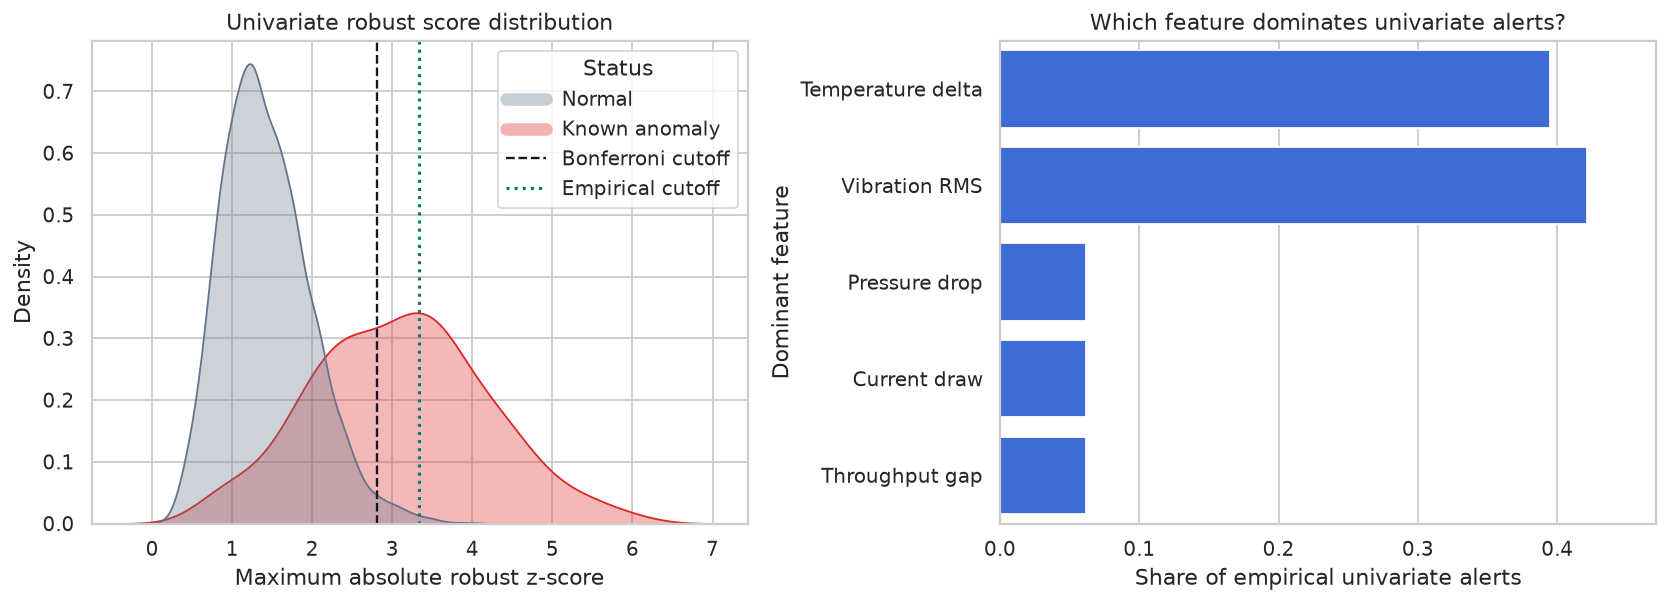

In [5]:
# Section focus: Discussion.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

sns.kdeplot(
    data=df,
    x='univariate_score',
    hue='known_anomaly',
    fill=True,
    common_norm=False,
    alpha=0.32,
    palette={0: '#64748b', 1: '#dc2626'},
    ax=axes[0],
)
axes[0].axvline(bonferroni_cutoff, color='#111827', linestyle='--', linewidth=1.3, label='Bonferroni cutoff')
axes[0].axvline(empirical_cutoff, color='#0f766e', linestyle=':', linewidth=1.7, label='Empirical cutoff')
axes[0].set_title('Univariate robust score distribution')
axes[0].set_xlabel('Maximum absolute robust z-score')
axes[0].set_ylabel('Density')
axes[0].legend(
    handles=[
        Line2D([0], [0], color='#64748b', linewidth=7, alpha=0.35, label='Normal'),
        Line2D([0], [0], color='#dc2626', linewidth=7, alpha=0.35, label='Known anomaly'),
        Line2D([0], [0], color='#111827', linestyle='--', linewidth=1.3, label='Bonferroni cutoff'),
        Line2D([0], [0], color='#0f766e', linestyle=':', linewidth=1.7, label='Empirical cutoff'),
    ],
    title='Status',
)

feature_alert_share = (
    df.loc[df['univariate_score'] >= empirical_cutoff, 'top_univariate_feature']
    .value_counts(normalize=True)
    .reindex(features)
    .fillna(0)
    .reset_index()
)
feature_alert_share.columns = ['feature', 'share_of_alerts']
feature_alert_share['feature_label'] = feature_alert_share['feature'].map(feature_display_names)
sns.barplot(data=feature_alert_share, x='share_of_alerts', y='feature_label', ax=axes[1], color='#2563eb')
axes[1].set_title('Which feature dominates univariate alerts?')
axes[1].set_xlabel('Share of empirical univariate alerts')
axes[1].set_ylabel('Dominant feature')
axes[1].set_xlim(0, max(0.45, feature_alert_share['share_of_alerts'].max() + 0.05))

plt.tight_layout()
plt.show()

The univariate score creates a very interpretable review rule: alert when at least one feature is individually extreme. The feature dominance plot also helps engineers understand what the queue will contain.

However, this detector has a narrow view of abnormality. It asks whether a point is far away along one coordinate. It does not ask whether the vector violates the usual relationship among features.

## 4. Multivariate Statistical Detectors

The Mahalanobis distance measures how far a vector is from a baseline mean after accounting for covariance:

$$
D_i^2 = (x_i - \hat{\mu})^\top \hat{\Sigma}^{-1}(x_i - \hat{\mu}).
$$

If $X$ is multivariate normal, and if $\mu$ and $\Sigma$ are known, then

$$
D_i^2 \sim \chi^2_p.
$$

This gives a parametric threshold:

$$
t_\alpha = \chi^2_{p,1-\alpha}.
$$

The practical difficulty is that $\hat{\mu}$ and $\hat{\Sigma}$ are estimated from data. If anomalies are present in the baseline window, classical covariance can be distorted. This is called contamination. It can create **masking**, where outliers make themselves look less unusual, and **swamping**, where normal points are incorrectly treated as outliers.

### Robust Covariance via Minimum Covariance Determinant

The minimum covariance determinant idea estimates location and covariance from a subset of $h$ observations whose covariance determinant is small:

$$
H^* = \arg\min_{H: |H|=h} \det(\hat{\Sigma}_H).
$$

Then robust distances use

$$
D_{i,\mathrm{robust}}^2 = (x_i - \hat{\mu}_{H^*})^\top \hat{\Sigma}_{H^*}^{-1}(x_i - \hat{\mu}_{H^*}).
$$

The intuition is simple: estimate the normal ellipsoid from the most internally consistent part of the data, then score all cases relative to that ellipsoid. The Fast-MCD algorithm makes this approach practical for moderate-dimensional data (Rousseeuw & Van Driessen, 1999; Hubert et al., 2017).

In [6]:
# Section focus: Robust Covariance via Minimum Covariance Determinant.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

X = df[features].to_numpy()
y = df['known_anomaly'].to_numpy()

emp_cov = EmpiricalCovariance().fit(X)
mcd_cov = MinCovDet(random_state=RANDOM_SEED, support_fraction=0.78).fit(X)

df['mahalanobis2_classical'] = emp_cov.mahalanobis(X)
df['mahalanobis2_robust'] = mcd_cov.mahalanobis(X)

chi2_cutoff = chi2.ppf(0.975, df=len(features))
classical_empirical_cutoff = df['mahalanobis2_classical'].quantile(0.975)
robust_empirical_cutoff = df['mahalanobis2_robust'].quantile(0.975)

multivariate_cutoffs = pd.DataFrame({
    'threshold_type': ['Chi-square 97.5%', 'Classical empirical 97.5%', 'Robust empirical 97.5%'],
    'cutoff_on_D2': [chi2_cutoff, classical_empirical_cutoff, robust_empirical_cutoff],
    'alert_rate_if_used': [
        (df['mahalanobis2_robust'] >= chi2_cutoff).mean(),
        (df['mahalanobis2_classical'] >= classical_empirical_cutoff).mean(),
        (df['mahalanobis2_robust'] >= robust_empirical_cutoff).mean(),
    ],
})
cutoff_display = multivariate_cutoffs.copy()
cutoff_display['cutoff_on_D2'] = cutoff_display['cutoff_on_D2'].map(lambda value: f'{value:.2f}')
cutoff_display['alert_rate_if_used'] = cutoff_display['alert_rate_if_used'].map(lambda value: f'{value:.1%}')
smart_display(cutoff_display, max_width='760px')

,threshold_type,cutoff_on_D2,alert_rate_if_used
0,Chi-square 97.5%,12.83,6.0%
1,Classical empirical 97.5%,16.93,2.5%
2,Robust empirical 97.5%,22.79,2.5%


Robust Covariance via Minimum Covariance Determinant is less about the score itself and more about whether the score creates an actionable investigation path.


In [7]:
# Section focus: Robust Covariance via Minimum Covariance Determinant.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def detector_metrics(frame, score_col, cutoff, label):
    """Carry out the detector metrics step used in the 04. Univariate and Multivariate Statistical Detectors workflow.
    
    Parameters
    ----------
    frame : object
        Data frame containing the units evaluated by this helper.
    score_col : object
        Column name containing model scores, risks, priorities, or anomaly scores.
    cutoff : object
        Decision cutoff used to translate scores into actions or alerts.
    label : object
        Human-readable label used to name a model, scenario, metric, or plotted series.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    alert = frame[score_col] >= cutoff
    y = frame['known_anomaly'].eq(1)
    tp = int((alert & y).sum())
    fp = int((alert & ~y).sum())
    fn = int((~alert & y).sum())
    tn = int((~alert & ~y).sum())
    return {
        'detector': label,
        'score': score_col,
        'cutoff': cutoff,
        'alerts': int(alert.sum()),
        'alert_rate': alert.mean(),
        'precision': tp / (tp + fp) if tp + fp else np.nan,
        'recall': tp / (tp + fn) if tp + fn else np.nan,
        'false_positive_rate': fp / (fp + tn) if fp + tn else np.nan,
        'roc_auc': roc_auc_score(frame['known_anomaly'], frame[score_col]),
        'average_precision': average_precision_score(frame['known_anomaly'], frame[score_col]),
    }

metric_rows = [
    detector_metrics(df, 'univariate_score', empirical_cutoff, 'Univariate robust z, top 2.5%'),
    detector_metrics(df, 'mahalanobis2_classical', classical_empirical_cutoff, 'Classical Mahalanobis, top 2.5%'),
    detector_metrics(df, 'mahalanobis2_robust', robust_empirical_cutoff, 'Robust Mahalanobis, top 2.5%'),
    detector_metrics(df, 'mahalanobis2_robust', chi2_cutoff, 'Robust Mahalanobis, chi-square 97.5%'),
]
metrics = pd.DataFrame(metric_rows)
metrics_display = metrics.drop(columns=['score']).copy()
metrics_display['cutoff'] = metrics_display['cutoff'].map(lambda value: f'{value:.2f}')
for column in ['alert_rate', 'precision', 'recall', 'false_positive_rate', 'average_precision']:
    metrics_display[column] = metrics_display[column].map(lambda value: f'{value:.1%}')
metrics_display['roc_auc'] = metrics_display['roc_auc'].map(lambda value: f'{value:.3f}')
smart_display(metrics_display, max_width='1040px')

,detector,cutoff,alerts,alert_rate,precision,recall,false_positive_rate,roc_auc,average_precision
0,"Univariate robust z, top 2.5%",3.33,114,2.5%,86.8%,43.0%,0.3%,0.913,66.5%
1,"Classical Mahalanobis, top 2.5%",16.93,114,2.5%,93.9%,46.5%,0.2%,0.915,74.7%
2,"Robust Mahalanobis, top 2.5%",22.79,114,2.5%,99.1%,49.1%,0.0%,0.922,78.8%
3,"Robust Mahalanobis, chi-square 97.5%",12.83,274,6.0%,65.0%,77.4%,2.2%,0.922,78.8%


Read Robust Covariance via Minimum Covariance Determinant with the reviewer in mind. The value is in making the next investigation more focused.


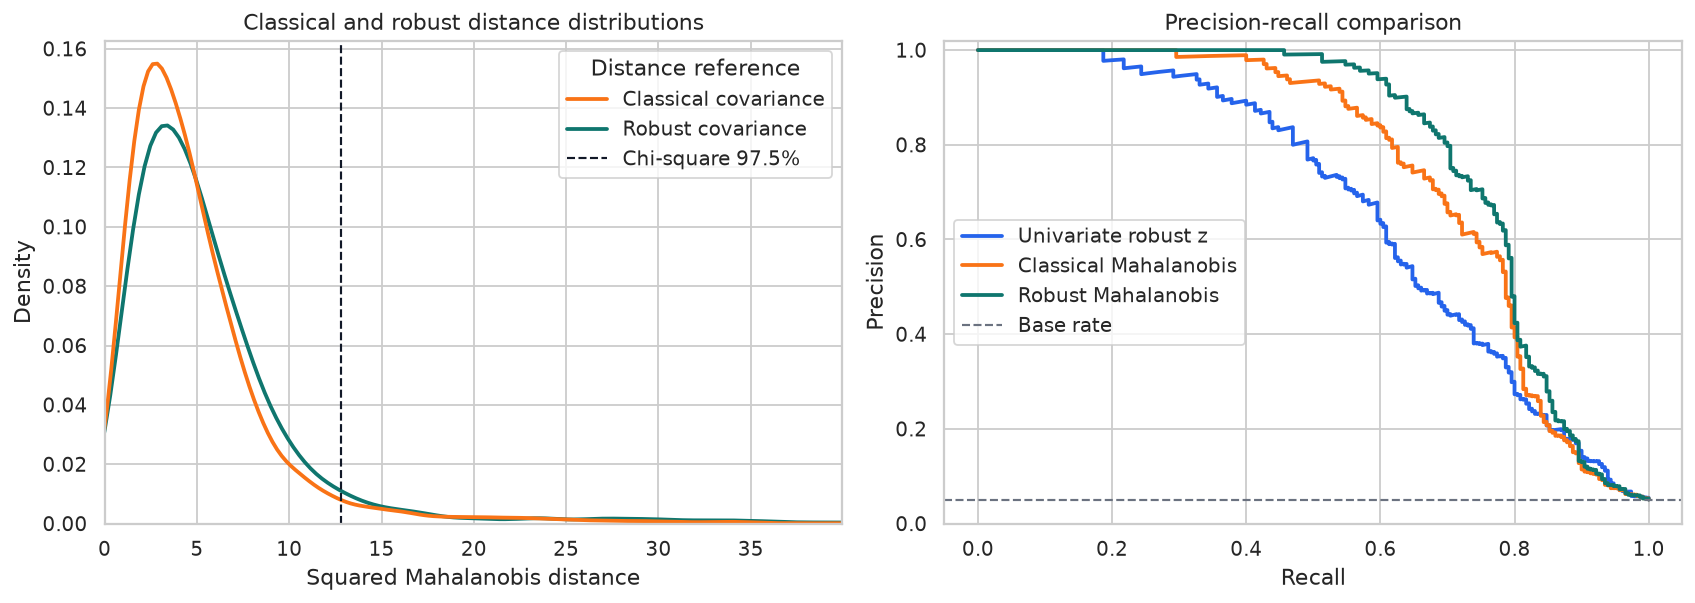

In [8]:
# Section focus: Robust Covariance via Minimum Covariance Determinant.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))

plot_df = df.copy()
plot_df['Known label'] = np.where(plot_df['known_anomaly'].eq(1), 'Known anomaly', 'Normal')
score_long = plot_df.melt(
    id_vars=['Known label'],
    value_vars=['mahalanobis2_classical', 'mahalanobis2_robust'],
    var_name='score_type',
    value_name='distance2',
)
score_long['score_type'] = score_long['score_type'].map({
    'mahalanobis2_classical': 'Classical covariance',
    'mahalanobis2_robust': 'Robust covariance',
})
sns.kdeplot(
    data=score_long,
    x='distance2',
    hue='score_type',
    hue_order=['Classical covariance', 'Robust covariance'],
    common_norm=False,
    fill=False,
    linewidth=2.1,
    palette={'Classical covariance': '#f97316', 'Robust covariance': '#0f766e'},
    ax=axes[0],
)
axes[0].axvline(chi2_cutoff, color='#111827', linestyle='--', linewidth=1.2)
axes[0].set_xlim(0, np.quantile(df['mahalanobis2_robust'], 0.995))
axes[0].set_title('Classical and robust distance distributions')
axes[0].set_xlabel('Squared Mahalanobis distance')
axes[0].set_ylabel('Density')
axes[0].legend(
    handles=[
        Line2D([0], [0], color='#f97316', linewidth=2.1, label='Classical covariance'),
        Line2D([0], [0], color='#0f766e', linewidth=2.1, label='Robust covariance'),
        Line2D([0], [0], color='#111827', linestyle='--', linewidth=1.2, label='Chi-square 97.5%'),
    ],
    title='Distance reference',
)

for score_col, label, color in [
    ('univariate_score', 'Univariate robust z', '#2563eb'),
    ('mahalanobis2_classical', 'Classical Mahalanobis', '#f97316'),
    ('mahalanobis2_robust', 'Robust Mahalanobis', '#0f766e'),
]:
    precision, recall, _ = precision_recall_curve(df['known_anomaly'], df[score_col])
    axes[1].plot(recall, precision, linewidth=2.1, label=label, color=color)
axes[1].axhline(df['known_anomaly'].mean(), color='#6b7280', linestyle='--', linewidth=1.2, label='Base rate')
axes[1].set_title('Precision-recall comparison')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_ylim(0, 1.02)
axes[1].legend()

plt.tight_layout()
plt.show()

The robust Mahalanobis detector is designed for the setting where the baseline sample is contaminated. It estimates the normal covariance structure from a cleaner subset, then scores every point against that structure.

The chi-square threshold is useful as a theoretical reference, but the empirical top-2.5% threshold is often easier to operate because it fixes alert volume. In production, a team may use both: the chi-square cutoff as a statistical benchmark and the empirical cutoff as a staffing control.

## 5. Geometry: Why Correlation Matters

A univariate detector creates rectangular alert regions: if any coordinate is too large, alert. A Mahalanobis detector creates ellipsoidal alert regions shaped by covariance. For two correlated variables, an observation can be moderate on each axis but still unusual as a combination.

For a two-feature vector $x_i = (x_{i1}, x_{i2})^\top$, the ellipse

$$
(x_i - \hat{\mu})^\top \hat{\Sigma}^{-1}(x_i - \hat{\mu}) = c
$$

contains points with the same Mahalanobis distance. Correlation rotates this ellipse. That rotation is the key difference between univariate and multivariate statistical detection.

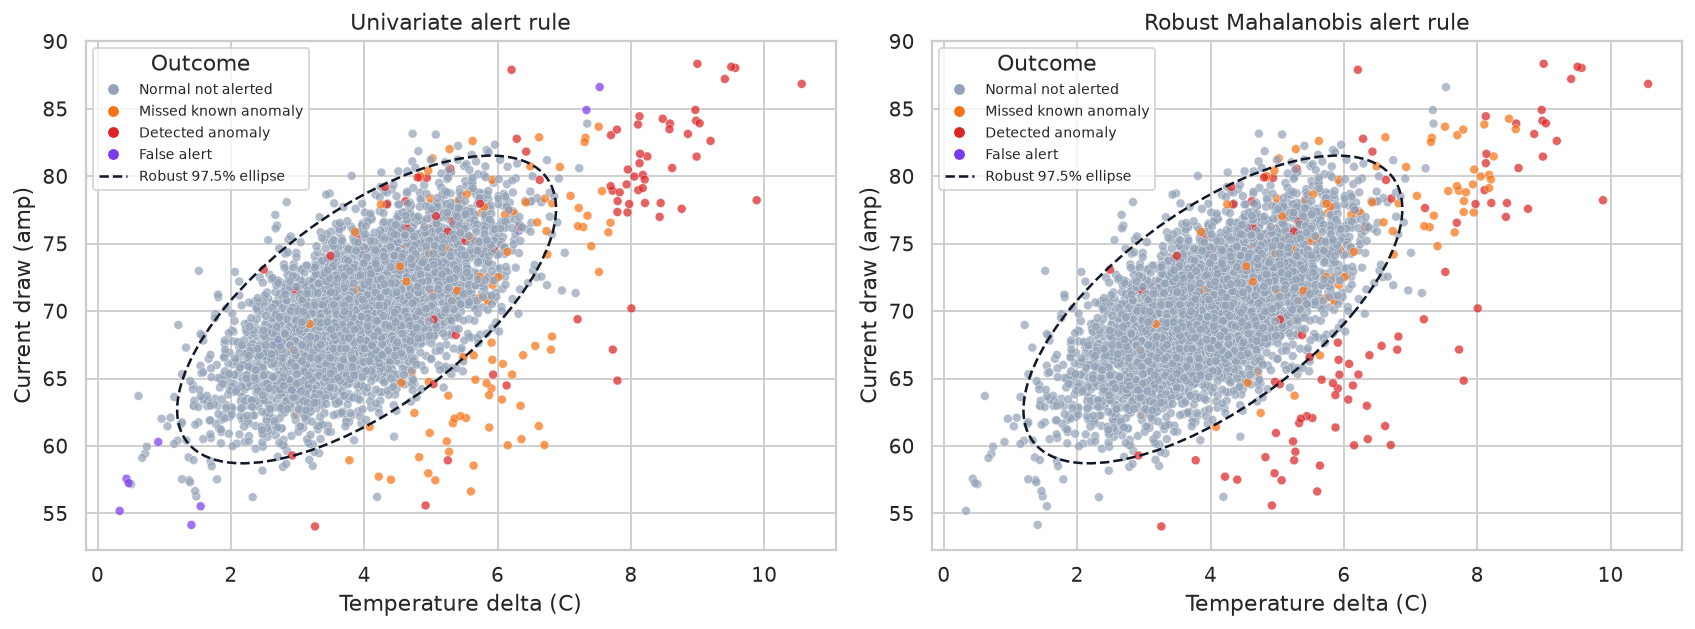

In [9]:
# Section focus: 5. Geometry: Why Correlation Matters.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def add_covariance_ellipse(ax, mean, cov, cutoff, **kwargs):
    """Carry out the add covariance ellipse step used in the 04. Univariate and Multivariate Statistical Detectors workflow.
    
    Parameters
    ----------
    ax : object
        Matplotlib axis on which the plot is drawn.
    mean : object
        The mean setting that controls the add covariance ellipse calculation in this notebook.
    cov : object
        The cov setting that controls the add covariance ellipse calculation in this notebook.
    cutoff : object
        Decision cutoff used to translate scores into actions or alerts.
    **kwargs : object
        Additional keyword arguments forwarded to the underlying model or helper.
    
    Returns
    -------
    object
        Intermediate result produced by the add covariance ellipse calculation and reused by later cells.
    """
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * np.sqrt(cutoff * vals)
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, fill=False, **kwargs)
    ax.add_patch(ellipse)
    return ellipse

pair = ['temperature_delta_c', 'current_draw_amp']
alert_uni = df['univariate_score'] >= empirical_cutoff
alert_robust = df['mahalanobis2_robust'] >= robust_empirical_cutoff

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.0))

status_order = ['Normal not alerted', 'Missed known anomaly', 'Detected anomaly', 'False alert']
palette = {
    'Normal not alerted': '#94a3b8',
    'False alert': '#7c3aed',
    'Missed known anomaly': '#f97316',
    'Detected anomaly': '#dc2626',
}

for ax, alert, title in [
    (axes[0], alert_uni, 'Univariate alert rule'),
    (axes[1], alert_robust, 'Robust Mahalanobis alert rule'),
]:
    status = np.select(
        [df['known_anomaly'].eq(1) & alert, df['known_anomaly'].eq(1) & ~alert, df['known_anomaly'].eq(0) & alert],
        ['Detected anomaly', 'Missed known anomaly', 'False alert'],
        default='Normal not alerted',
    )
    plot_data = df.assign(status=pd.Categorical(status, categories=status_order, ordered=True))
    sns.scatterplot(
        data=plot_data.sample(frac=1, random_state=RANDOM_SEED),
        x=pair[0],
        y=pair[1],
        hue='status',
        hue_order=status_order,
        palette=palette,
        s=24,
        alpha=0.72,
        edgecolor='white',
        linewidth=0.25,
        ax=ax,
        legend=False,
    )
    add_covariance_ellipse(
        ax,
        mcd_cov.location_[[features.index(pair[0]), features.index(pair[1])]],
        mcd_cov.covariance_[np.ix_([features.index(pair[0]), features.index(pair[1])], [features.index(pair[0]), features.index(pair[1])])],
        chi2.ppf(0.975, 2),
        edgecolor='#111827',
        linestyle='--',
        linewidth=1.4,
    )
    ax.set_title(title)
    ax.set_xlabel('Temperature delta (C)')
    ax.set_ylabel('Current draw (amp)')
    ax.legend(
        handles=[
            Line2D([0], [0], marker='o', color='white', markerfacecolor=palette['Normal not alerted'], markeredgecolor='white', markersize=7, label='Normal not alerted'),
            Line2D([0], [0], marker='o', color='white', markerfacecolor=palette['Missed known anomaly'], markeredgecolor='white', markersize=7, label='Missed known anomaly'),
            Line2D([0], [0], marker='o', color='white', markerfacecolor=palette['Detected anomaly'], markeredgecolor='white', markersize=7, label='Detected anomaly'),
            Line2D([0], [0], marker='o', color='white', markerfacecolor=palette['False alert'], markeredgecolor='white', markersize=7, label='False alert'),
            Line2D([0], [0], color='#111827', linestyle='--', linewidth=1.4, label='Robust 97.5% ellipse'),
        ],
        title='Outcome',
        loc='upper left',
        fontsize=8,
    )

plt.tight_layout()
plt.show()

The ellipse is not the full five-dimensional detector; it is a two-dimensional view of the covariance geometry. Still, it shows the central idea. Multivariate detectors judge points relative to the shape of normal variation, rather than only relative to one-dimensional cutoffs.

This matters in reliability, fraud, operations, and security monitoring. A case may not be extreme on any individual variable, but the combination can still be implausible under normal operations.

## 6. Which Anomaly Types Are Captured?

A detector can look good in aggregate while failing a particular failure mode. The next table breaks recall down by known anomaly type. This is crucial for decision science because operational value often depends on which failures are caught as well as how many failures are caught.

In [10]:
# Section focus: 6. Which Anomaly Types Are Captured?.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def recall_by_type(frame, score_col, cutoff, detector_name):
    """Carry out the recall by type step used in the 04. Univariate and Multivariate Statistical Detectors workflow.
    
    Parameters
    ----------
    frame : object
        Data frame containing the units evaluated by this helper.
    score_col : object
        Column name containing model scores, risks, priorities, or anomaly scores.
    cutoff : object
        Decision cutoff used to translate scores into actions or alerts.
    detector_name : object
        The detector name setting that controls the recall by type calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the recall by type calculation and reused by later cells.
    """
    rows = []
    for anomaly_type, group in frame.loc[frame['known_anomaly'].eq(1)].groupby('anomaly_type'):
        rows.append({
            'detector': detector_name,
            'anomaly_type': anomaly_type,
            'known_cases': len(group),
            'recall': (group[score_col] >= cutoff).mean(),
            'median_score': group[score_col].median(),
        })
    return rows

recall_type_rows = []
recall_type_rows.extend(recall_by_type(df, 'univariate_score', empirical_cutoff, 'Univariate robust z'))
recall_type_rows.extend(recall_by_type(df, 'mahalanobis2_classical', classical_empirical_cutoff, 'Classical Mahalanobis'))
recall_type_rows.extend(recall_by_type(df, 'mahalanobis2_robust', robust_empirical_cutoff, 'Robust Mahalanobis'))
recall_by_type_table = pd.DataFrame(recall_type_rows)

recall_display = recall_by_type_table.copy()
recall_display['recall'] = recall_display['recall'].map(lambda value: f'{value:.1%}')
recall_display['median_score'] = recall_display['median_score'].map(lambda value: f'{value:.2f}')
smart_display(recall_display, max_width='920px')

,detector,anomaly_type,known_cases,recall,median_score
0,Univariate robust z,compound_drift,48,8.3%,2.02
1,Univariate robust z,correlation_break,53,18.9%,2.53
2,Univariate robust z,thermal_spike,63,63.5%,3.56
3,Univariate robust z,vibration_spike,66,68.2%,3.77
4,Classical Mahalanobis,compound_drift,48,2.1%,6.30
5,Classical Mahalanobis,correlation_break,53,83.0%,21.67
6,Classical Mahalanobis,thermal_spike,63,39.7%,16.23
7,Classical Mahalanobis,vibration_spike,66,56.1%,18.95
8,Robust Mahalanobis,compound_drift,48,2.1%,7.30
9,Robust Mahalanobis,correlation_break,53,86.8%,31.41


In Which Anomaly Types Are Captured?, the useful signal is the part that survives contact with seasonality, measurement noise, and routine variation.


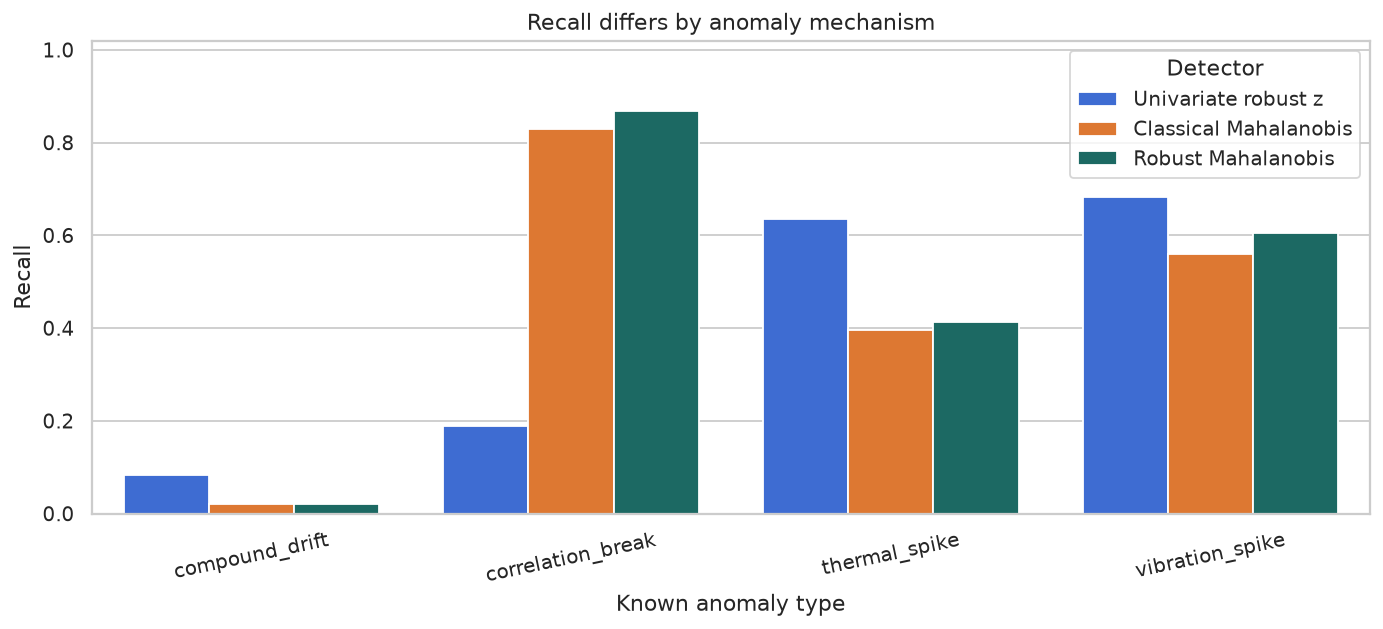

In [11]:
fig, ax = plt.subplots(figsize=(10.8, 5.0))
plot_recall = recall_by_type_table.copy()
sns.barplot(
    data=plot_recall,
    x='anomaly_type',
    y='recall',
    hue='detector',
    palette=['#2563eb', '#f97316', '#0f766e'],
    ax=ax,
)
ax.set_title('Recall differs by anomaly mechanism')
ax.set_xlabel('Known anomaly type')
ax.set_ylabel('Recall')
ax.set_ylim(0, 1.02)
ax.tick_params(axis='x', rotation=12)
ax.legend(title='Detector', loc='upper right')
plt.tight_layout()
plt.show()

A strong statistical detector is not necessarily strong for every operational failure mode. Univariate rules tend to do well on single-signal spikes. Multivariate rules tend to improve detection of combination failures. If the business cares most about one failure type, threshold selection should be evaluated for that type explicitly.

## 7. Explaining Statistical Alerts

Statistical detectors are often treated as simple, but the alerts still need explanation. For univariate alerts, the explanation is the dominant robust z-score. For Mahalanobis alerts, a practical explanation is to show standardized deviations from the robust center.

This is not a perfect decomposition of Mahalanobis distance because covariance couples the variables. But it is useful for triage: it tells an analyst which measurements are most responsible for the case looking unusual.

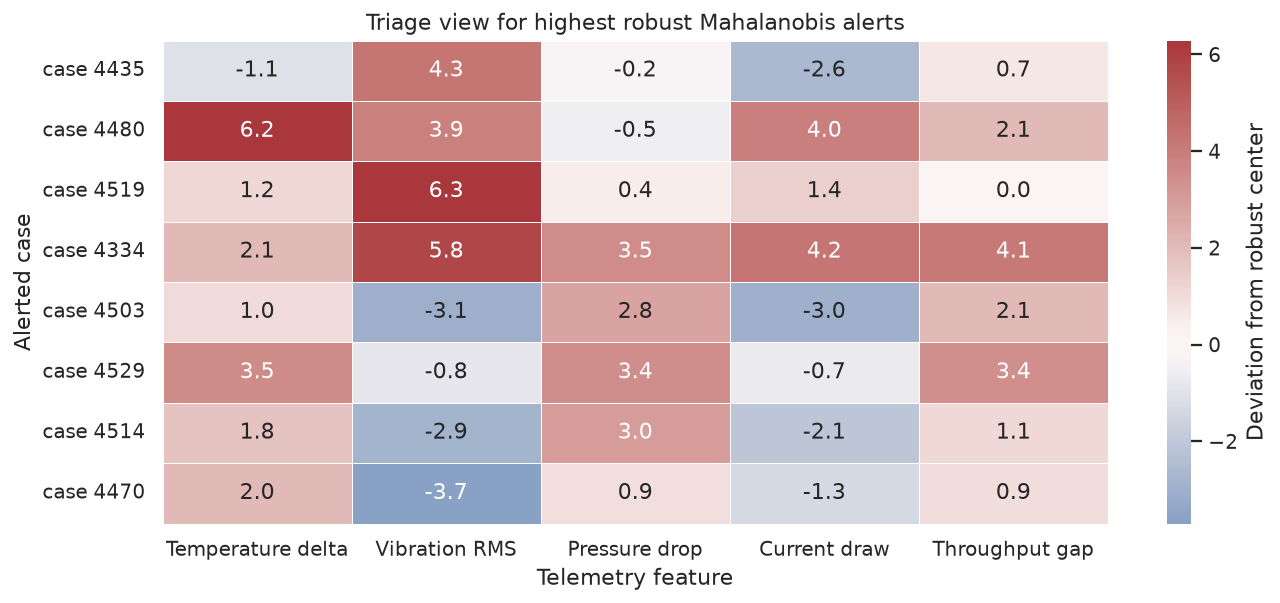

,case_id,anomaly_type,mahalanobis2_robust,univariate_score,top_univariate_feature
0,4435,vibration_spike,55.4,4.0,vibration_rms_mm_s
1,4480,thermal_spike,52.7,6.0,temperature_delta_c
2,4519,vibration_spike,51.6,5.9,vibration_rms_mm_s
3,4334,vibration_spike,51.6,5.5,vibration_rms_mm_s
4,4503,correlation_break,49.6,3.0,current_draw_amp
5,4529,correlation_break,49.0,3.4,throughput_gap_pct
6,4514,correlation_break,48.6,3.0,pressure_drop_kpa
7,4470,correlation_break,47.7,3.5,vibration_rms_mm_s


In [12]:
# Section focus: 7. Explaining Statistical Alerts.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

robust_center = pd.Series(mcd_cov.location_, index=features)
robust_scale = pd.Series(np.sqrt(np.diag(mcd_cov.covariance_)), index=features)
robust_standardized = (df[features] - robust_center) / robust_scale

selected_alerts = (
    df.assign(robust_alert=alert_robust)
    .loc[lambda data: data['robust_alert']]
    .sort_values('mahalanobis2_robust', ascending=False)
    .head(8)
    .copy()
)
selected_indices = selected_alerts.index
heatmap_data = robust_standardized.loc[selected_indices, features].copy()
heatmap_data.index = [f'case {idx}' for idx in selected_indices]
heatmap_data = heatmap_data.rename(columns=feature_display_names)

fig, ax = plt.subplots(figsize=(10.6, 4.8))
sns.heatmap(
    heatmap_data,
    cmap='vlag',
    center=0,
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cbar_kws={'label': 'Deviation from robust center'},
    ax=ax,
)
ax.set_title('Triage view for highest robust Mahalanobis alerts')
ax.set_xlabel('Telemetry feature')
ax.set_ylabel('Alerted case')
plt.tight_layout()
plt.show()

case_explanations = selected_alerts[['anomaly_type', 'mahalanobis2_robust', 'univariate_score', 'top_univariate_feature']].copy()
case_explanations['mahalanobis2_robust'] = case_explanations['mahalanobis2_robust'].map(lambda value: f'{value:.1f}')
case_explanations['univariate_score'] = case_explanations['univariate_score'].map(lambda value: f'{value:.1f}')
smart_display(case_explanations.reset_index(names='case_id'), max_width='900px')

The heatmap turns a statistical score into an engineering conversation. The model says, "this vector is far from the robust normal ellipsoid." The triage view says which measurements pushed it there.

For governance, this explanation should be logged with the alert. If an engineer closes the alert as not actionable, that feedback becomes evidence for changing the threshold, changing features, or segmenting the baseline.

## 8. Detector Selection as a Decision

The statistical comparison is not enough by itself. A deployment decision should consider:

| Question | Why it matters |
|---|---|
| What anomaly mechanism matters most? | Different detectors catch different failure modes. |
| What alert rate can the team staff? | A statistically attractive threshold can overload review. |
| Is the baseline contaminated? | Classical covariance can be distorted by existing anomalies. |
| Are normal regions elliptical? | Mahalanobis distance assumes covariance geometry is meaningful. |
| Does the detector produce usable explanations? | Review teams need enough context to act. |
| Will thresholds be monitored over time? | Score distributions drift with seasonality, maintenance, and sensor changes. |

A statistical detector is most useful when it becomes a repeatable decision workflow rather than an isolated score.

In [13]:
# Section focus: 8. Detector Selection as a Decision.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

recommended = metrics.loc[metrics['detector'].eq('Robust Mahalanobis, top 2.5%')].iloc[0]
univariate = metrics.loc[metrics['detector'].eq('Univariate robust z, top 2.5%')].iloc[0]

memo = pd.DataFrame({
    'Memo item': [
        'Recommended first-pass detector',
        'Why this detector?',
        'Operating threshold',
        'Expected queue size',
        'Expected precision and recall',
        'Univariate backup rule',
        'Main limitation',
        'Monitoring plan',
    ],
    'Decision note': [
        'Use robust Mahalanobis distance with an empirical top-2.5% review threshold.',
        'It accounts for normal correlation structure and is less vulnerable to covariance contamination than the classical estimator.',
        f"Flag cases with robust squared Mahalanobis distance at or above {robust_empirical_cutoff:.2f}.",
        f"Expected alert rate is {recommended['alert_rate']:.1%}, or about {int(recommended['alerts'])} telemetry windows in this batch.",
        f"Estimated precision is {recommended['precision']:.1%}; estimated recall is {recommended['recall']:.1%} against the synthetic known labels.",
        f"Keep the univariate robust z rule as a simple diagnostic layer; at the same alert rate it has recall {univariate['recall']:.1%}.",
        'Mahalanobis geometry assumes an ellipsoidal normal region; nonlinear clusters or segment-specific baselines may require later methods.',
        'Track alert volume, precision from engineer dispositions, recall by failure type when labels arrive, and shifts in robust center/covariance.',
    ],
})
smart_display(memo, max_width='980px')

,Memo item,Decision note
0,Recommended first-pass detector,Use robust Mahalanobis distance with an empirical top-2.5% review threshold.
1,Why this detector?,It accounts for normal correlation structure and is less vulnerable to covariance contamination than the classical estimator.
2,Operating threshold,Flag cases with robust squared Mahalanobis distance at or above 22.79.
3,Expected queue size,"Expected alert rate is 2.5%, or about 114 telemetry windows in this batch."
4,Expected precision and recall,Estimated precision is 99.1%; estimated recall is 49.1% against the synthetic known labels.
5,Univariate backup rule,Keep the univariate robust z rule as a simple diagnostic layer; at the same alert rate it has recall 43.0%.
6,Main limitation,Mahalanobis geometry assumes an ellipsoidal normal region; nonlinear clusters or segment-specific baselines may require later methods.
7,Monitoring plan,"Track alert volume, precision from engineer dispositions, recall by failure type when labels arrive, and shifts in robust center/covariance."


For Detector Selection as a Decision, focus on what the alert would make an analyst do next: investigate, suppress, monitor, or revise the rule.


## Key Takeaways

- Univariate robust z-scores are transparent and useful for single-signal spikes.
- Multiple monitored variables create multiple false-alert opportunities, so row-level threshold design matters.
- Mahalanobis distance detects unusual vectors, rather than only unusual coordinates.
- Classical covariance can be contaminated by the same anomalies we want to detect.
- Robust covariance methods such as MCD estimate the normal ellipsoid from a cleaner subset of the data.
- The chi-square threshold is a useful statistical reference, but empirical thresholds often align better with staffing constraints.
- Detector evaluation should be broken down by anomaly mechanism, alongside aggregate scores.
- Statistical alerts still need explanations, triage views, and monitoring plans.

## References

Chandola, V., Banerjee, A., & Kumar, V. (2009). Anomaly detection. *ACM Computing Surveys, 41*(3), 1-58. [https://doi.org/10.1145/1541880.1541882](https://doi.org/10.1145/1541880.1541882)

Holst, A., Bohlin, M., & Ekman, J. (2013). Statistical anomaly detection for train fleets. *AI Magazine, 34*(1), 33-42. [https://doi.org/10.1609/aimag.v34i1.2435](https://doi.org/10.1609/aimag.v34i1.2435)

Hubert, M., Debruyne, M., & Rousseeuw, P. J. (2017). Minimum covariance determinant and extensions. *Wiley Interdisciplinary Reviews: Computational Statistics, 10*(3). [https://doi.org/10.1002/wics.1421](https://doi.org/10.1002/wics.1421)

Mastrangelo, C. M., Runger, G. C., & Montgomery, D. C. (1996). Statistical process monitoring with principal components. *Quality and Reliability Engineering International, 12*(3), 203-210. [https://doi.org/10.1002/(SICI)1099-1638(199605)12:3%3C203::AID-QRE12%3E3.0.CO;2-B](https://doi.org/10.1002/%28SICI%291099-1638%28199605%2912:3%3C203::AID-QRE12%3E3.0.CO;2-B)

Rousseeuw, P. J., & Van Driessen, K. (1999). A fast algorithm for the minimum covariance determinant estimator. *Technometrics, 41*(3), 212-223. [https://doi.org/10.1080/00401706.1999.10485670](https://doi.org/10.1080/00401706.1999.10485670)
